Var(X_t) target: 0.5535980700866608
Mean of v_t (last step): 0.07662322787798252 Expected xi0: 0.1


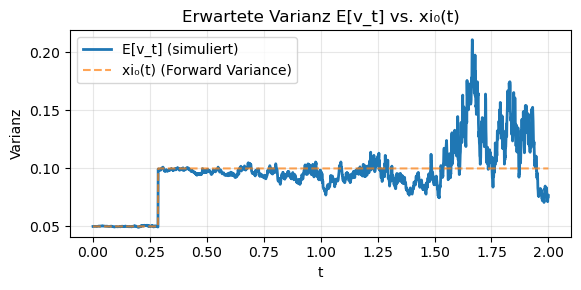

Params: {'eta': 3, 'rho': -0.5, 'H': 0.4, 'xi0_knots': array([0.05, 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 ])}
Example shifted strikes: [0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5]
Example shifted maturities: [0.1 0.3 0.6 0.9 1.2 1.5 1.8 2. ]
IV surface shape: (8, 11)


In [158]:
# Rough Bergomi IV surfaces via rDonsker fBm — Stable IV Extraction + OTM Options
# --------------------------------------------------------------------------------------------------------
# Features:
# - Constant time grid (consistent discretization)
# - Randomized Maturities (±15%)
# - OTM pricing (Calls for K>=S0, Puts for K<S0)
# - Stable implied vol inversion (clipping + NaN handling)
# - Piecewise constant xi0, Antithetic variates, batch seeding
# --------------------------------------------------------------------------------------------------------

import numpy as np
from dataclasses import dataclass
from typing import List, Dict
from scipy.stats import norm

# -------------------------------------------------------------
# Parameter structures
# -------------------------------------------------------------

@dataclass
class RBergomiParams:
    eta: float
    rho: float
    H: float
    xi0_knots: np.ndarray

@dataclass
class SimulationConfig:
    M: int = 20000
    n: int = 1200
    T_max: float = 2.0
    S0: float = 1.0
    strikes: np.ndarray = None
    maturities: np.ndarray = None
    batch_size: int = 5000
    G: int = 10

    def __post_init__(self):
        if self.strikes is None:
            self.strikes = np.array([0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5])
        if self.maturities is None:
            self.maturities = np.array([0.1,0.3,0.6,0.9,1.2,1.5,1.8,2.0])

# -------------------------------------------------------------
# rDonsker fractional Brownian motion simulator
# -------------------------------------------------------------

def fBm_path_rDonsker(grid_points: int, M: int, H: float, T: float) -> np.ndarray:
    """
    rDonsker fractional Brownian motion paths with correct variance scaling.
    Ensures Var[X_t] ≈ t^{2H}.
    """
    dt = 1 / (grid_points - 1)
    dw = np.random.normal(0.0, (dt**H), size=(M, grid_points - 1))
    i = np.arange(1, grid_points)
    # "Optimal" Donsker kernel (from Bayer, Friz, Gatheral 2016)
    opt_k = ((i**(2*H) - (i-1)**(2*H)) / (2*H)) ** 0.5

    Y = np.zeros((M, grid_points))
    for m in range(M):
        conv = np.convolve(opt_k, dw[m, :])[:grid_points - 1]
        Y[m, 1:] = conv

    # empirically normalize to Var[X_T] = T^{2H}
    scale = T**H*np.sqrt(2*H)
    Y *= scale
    return Y

# -------------------------------------------------------------
# Piecewise constant forward variance curve
# -------------------------------------------------------------

def build_xi0_piecewise_constant(knots: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    T_max = t_grid[-1]
    knot_times = np.linspace(0.0, T_max, len(knots))
    idx = np.digitize(t_grid, knot_times) - 1
    idx = np.clip(idx, 0, len(knots) - 1)
    return knots[idx]

# -------------------------------------------------------------
# Price simulation with correlated Brownian motions
# -------------------------------------------------------------

def simulate_price_paths(S0: float, t: np.ndarray, X: np.ndarray, dw: np.ndarray, dW_perp: np.ndarray,
                         xi0_t: np.ndarray, eta: float, rho: float, H: float) -> np.ndarray:
    n = min(X.shape[1], t.shape[0], dw.shape[1] + 1, xi0_t.shape[0])
    X, t, xi0_t = X[:, :n], t[:n], xi0_t[:n]
    dw, dW_perp = dw[:, :n-1], dW_perp[:, :n-1]
    M = X.shape[0]
    dt = np.mean(np.diff(t))
    t2H = np.power(t, 2.0*H)
    exp_term = np.clip(eta * X - 0.5 * eta**2 * t2H, -1000, 1000)
    v = xi0_t * np.exp(exp_term)
    dW_S = rho * dw + np.sqrt(max(1.0 - rho*rho, 0.0)) * dW_perp
    logS = np.zeros((M, n))
    logS[:, 0] = np.log(S0)
    logS[:, 1:] = logS[:, [0]] + np.cumsum(-0.5*v[:, :-1]*dt + np.sqrt(np.maximum(v[:, :-1], 0.0))*dW_S, axis=1)
    return np.exp(logS)


# -------------------------------------------------------------
# Plain OTM pricing (no control variate)
# -------------------------------------------------------------

def price_calls_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    return np.mean(np.maximum(ST[:, None] - Ks[None, :], 0.0), axis=0)

def price_puts_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    return np.mean(np.maximum(Ks[None, :] - ST[:, None], 0.0), axis=0)

def price_otm_plain(ST: np.ndarray, S0: float, Ks: np.ndarray) -> np.ndarray:
    calls = price_calls_plain(ST, S0, Ks)
    puts = price_puts_plain(ST, S0, Ks)
    return np.where(Ks >= S0, calls, puts)

# -------------------------------------------------------------
# Black–Scholes pricing + implied vol inversion (robust)
# -------------------------------------------------------------

def bs_call_price(S0, K, T, vol):
    if vol <= 0.0 or T <= 0.0:
        return max(S0 - K, 0.0)
    sT = np.sqrt(T)
    d1 = (np.log(S0 / K) + 0.5 * vol**2 * T) / (vol * sT)
    d2 = d1 - vol * sT
    return S0 * norm.cdf(d1) - K * norm.cdf(d2)

def bs_put_price(S0, K, T, vol):
    if vol <= 0.0 or T <= 0.0:
        return max(K - S0, 0.0)
    sT = np.sqrt(T)
    d1 = (np.log(S0 / K) + 0.5 * vol**2 * T) / (vol * sT)
    d2 = d1 - vol * sT
    return K * norm.cdf(-d2) - S0 * norm.cdf(-d1)

def implied_vol_from_price_otm(S0, K, T, price, tol=1e-7):
    if price < 1e-8:
        return np.nan
    price_func = bs_call_price if K >= S0 else bs_put_price
    a, b = 1e-8, 5.0
    fa = price_func(S0, K, T, a) - price
    fb = price_func(S0, K, T, b) - price
    if fa * fb > 0:
        return np.nan
    for _ in range(80):
        m = 0.5 * (a + b)
        fm = price_func(S0, K, T, m) - price
        if np.sign(fm) == np.sign(fa):
            a, fa = m, fm
        else:
            b, fb = m, fm
        if abs(b - a) < tol:
            break
    vol = max(0.0, 0.5 * (a + b))
    return np.clip(vol, 0.01, 3.0)

def surface_implied_vols_otm(S0, Ks, T, prices):
    ivs = [implied_vol_from_price_otm(S0, float(K), float(T), float(p)) for K, p in zip(Ks, prices)]
    return np.nan_to_num(np.array(ivs), nan=0.05)

# -------------------------------------------------------------
# Parameter sampling
# -------------------------------------------------------------

def sample_param_set() -> RBergomiParams:
    xi0_knots = np.array([0.05,  0.1 ,  0.1 ,  0.1   ,  0.1,
        0.1,  0.1,  0.1])
    eta = 3
    rho = -0.5
    H = 0.4
    return RBergomiParams(eta=eta, rho=rho, H=H, xi0_knots=xi0_knots)

# -------------------------------------------------------------
# Main workflow
# -------------------------------------------------------------

def generate_surfaces(num_sets=1, forward_curves_per_set=1, cfg=SimulationConfig(), seed=42) -> List[Dict]:
    np.random.seed(seed)
    results = []
    n, T_max = cfg.n, cfg.T_max
    base_t = np.linspace(0.0, T_max, n)
    dt = base_t[1] - base_t[0]

    for s in range(num_sets):
        params = sample_param_set()
        np.random.seed(seed + s)

        M_half = cfg.M // 2
        dw_half = np.random.normal(0.0, np.sqrt(dt), size=(M_half, n - 1))
        dW_perp_half = np.random.normal(0.0, np.sqrt(dt), size=(M_half, n - 1))
        dw = np.vstack([dw_half, -dw_half])
        dW_perp = np.vstack([dW_perp_half, -dW_perp_half])

        X = fBm_path_rDonsker(n, cfg.M, params.H, T_max)
        grids = [base_t.copy()] * cfg.G

        for j in range(forward_curves_per_set):
            knots = params.xi0_knots
            for g_id, t in enumerate(grids):
                T_shift = 0#np.random.uniform(-0.15, 0.15)
                maturities_shifted = np.clip(cfg.maturities + T_shift, 0.05, T_max)
                strikes_shifted = np.clip(cfg.strikes, 0.5, 1.5)

                xi0_t = build_xi0_piecewise_constant(knots, t)
                S = simulate_price_paths(cfg.S0, t, X, dw, dW_perp, xi0_t, params.eta, params.rho, params.H)
                t2H = np.power(t, 2.0 * params.H)
                v_t = xi0_t*np.exp(params.eta * X - 0.5 * params.eta**2 * t2H)
                avg_v = np.mean(v_t, axis=0)
                print("Var(X_t) target:", np.mean(np.var(X, axis=0)) / np.power(T_max, 2*params.H))
                print("Mean of v_t (last step):", np.mean(v_t[:, -1]), "Expected xi0:", xi0_t[-1])
                import matplotlib.pyplot as plt
                plt.figure(figsize=(6, 3))
                plt.plot(t, avg_v, label="E[v_t] (simuliert)", lw=2)
                plt.plot(t, xi0_t, "--", label="xi₀(t) (Forward Variance)", alpha=0.7)
                plt.xlabel("t")
                plt.ylabel("Varianz")
                plt.title("Erwartete Varianz E[v_t] vs. xi₀(t)")
                plt.legend()
                plt.grid(alpha=0.3)
                plt.tight_layout()
                plt.show()

                mat_idx = [np.argmin(np.abs(t - Tm)) for Tm in maturities_shifted]
                price_surf = np.zeros((len(maturities_shifted), len(strikes_shifted)))
                iv_surf = np.zeros_like(price_surf)

                for mi, idx in enumerate(mat_idx):
                    ST = S[:, idx]
                    prices = price_otm_plain(ST, cfg.S0, strikes_shifted)
                    price_surf[mi, :] = prices
                    iv_surf[mi, :] = surface_implied_vols_otm(cfg.S0, strikes_shifted, t[idx], prices)

                results.append({
                    "set_id": s,
                    "fwd_id": j,
                    "grid_id": g_id,
                    "params": vars(params),
                    "grid": {
                        "strikes": strikes_shifted.astype(float),
                        "maturities": maturities_shifted.astype(float),
                    },
                    "price_surface": price_surf,
                    "iv_surface": iv_surf,
                })
    return results

# -------------------------------------------------------------
# Example run
# -------------------------------------------------------------

if __name__ == "__main__":
    cfg = SimulationConfig(M=50000, n=2000, T_max=2.0, S0=1.0, G=1)
    surfaces = generate_surfaces(num_sets=1, forward_curves_per_set=1, cfg=cfg)
    R0 = surfaces[0]
    print("Params:", R0["params"])
    print("Example shifted strikes:", R0["grid"]["strikes"])
    print("Example shifted maturities:", R0["grid"]["maturities"])
    print("IV surface shape:", R0["iv_surface"].shape)


In [160]:
surfaces[0]["iv_surface"]

array([[0.05      , 0.05      , 0.33507255, 0.28443937, 0.23400244,
        0.20903868, 0.2287845 , 0.26482624, 0.30673889, 0.34554888,
        0.37863594],
       [0.46279167, 0.38259205, 0.31460148, 0.26025695, 0.21601495,
        0.19369726, 0.21041867, 0.24217826, 0.27452421, 0.30427207,
        0.3320003 ],
       [0.43581975, 0.36913511, 0.31142232, 0.26084249, 0.21983636,
        0.19896534, 0.21395561, 0.24272193, 0.27270784, 0.3010415 ,
        0.32663633],
       [0.39677558, 0.33851852, 0.28764431, 0.24299567, 0.20711889,
        0.18727903, 0.20048109, 0.22535463, 0.25122215, 0.27561714,
        0.29800099],
       [0.36891905, 0.31493475, 0.26784454, 0.22687768, 0.194279  ,
        0.17517482, 0.18700217, 0.20946656, 0.23305845, 0.25535655,
        0.2758715 ],
       [0.34142238, 0.29191059, 0.24869551, 0.21108155, 0.18121493,
        0.16271968, 0.17346111, 0.19396213, 0.21563937, 0.23621422,
        0.25503878],
       [0.31847854, 0.27251941, 0.23261135, 0.19782183, 0.

In [5]:
surfaces[0]["price_surface"]

array([[0.00000000e+00, 0.00000000e+00, 2.02341819e-05, 8.75232728e-04,
        9.74270932e-03, 4.42836052e-02, 1.26784758e-02, 2.62434785e-03,
        4.25578906e-04, 5.65370966e-05, 6.59232458e-06],
       [1.91134889e-05, 2.65974305e-04, 2.23015930e-03, 1.06178855e-02,
        3.32656701e-02, 7.64372094e-02, 3.99918662e-02, 1.95278939e-02,
        9.10871569e-03, 4.10455544e-03, 1.80689034e-03],
       [5.89515766e-04, 3.02207728e-03, 1.07063807e-02, 2.83615065e-02,
        5.99977777e-02, 1.07662903e-01, 7.01619000e-02, 4.46982590e-02,
        2.80723298e-02, 1.74653927e-02, 1.09147838e-02],
       [2.70016511e-03, 8.84932544e-03, 2.24337761e-02, 4.67802097e-02,
        8.41379191e-02, 1.34425490e-01, 9.68741994e-02, 6.92686341e-02,
        4.93744549e-02, 3.52337702e-02, 2.52715110e-02],
       [5.09520805e-03, 1.40156334e-02, 3.12323739e-02, 5.92279147e-02,
        9.92518545e-02, 1.51012585e-01, 1.13663164e-01, 8.53004949e-02,
        6.40818887e-02, 4.82341147e-02, 3.65658941e-

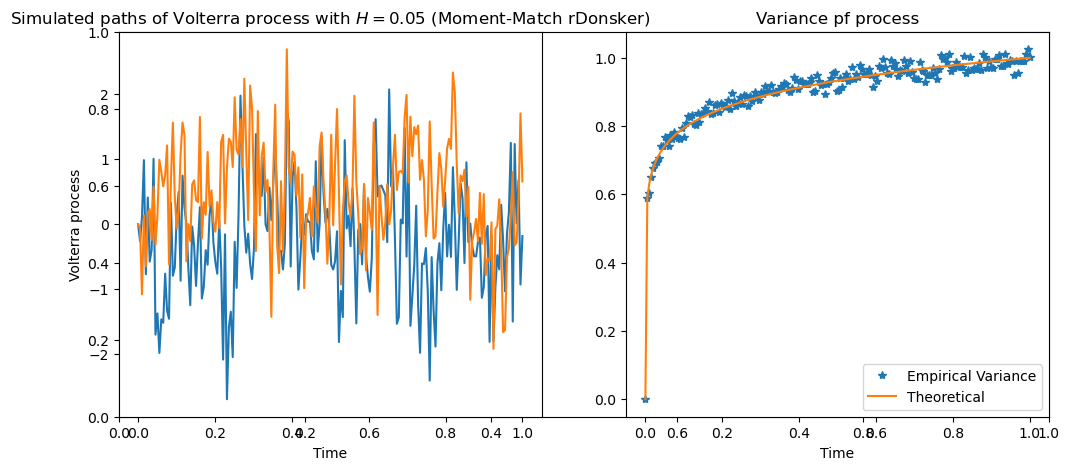

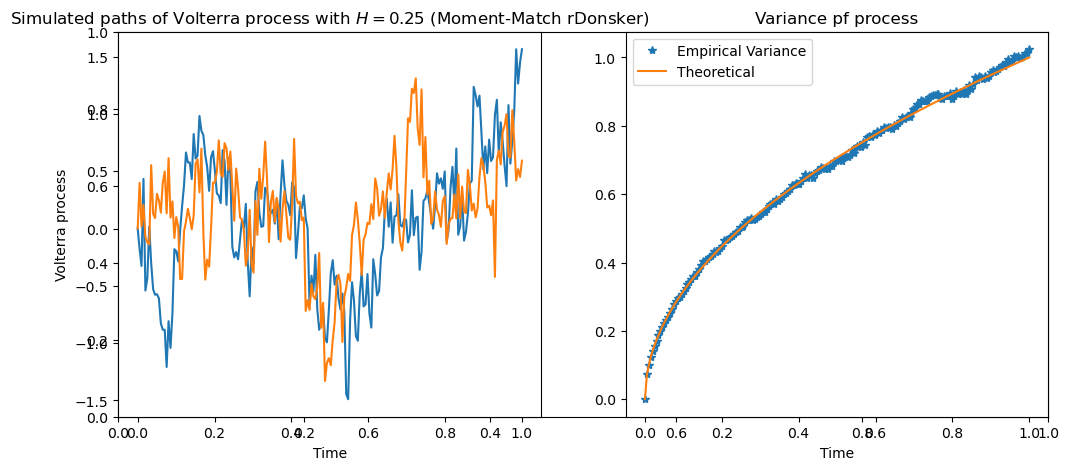

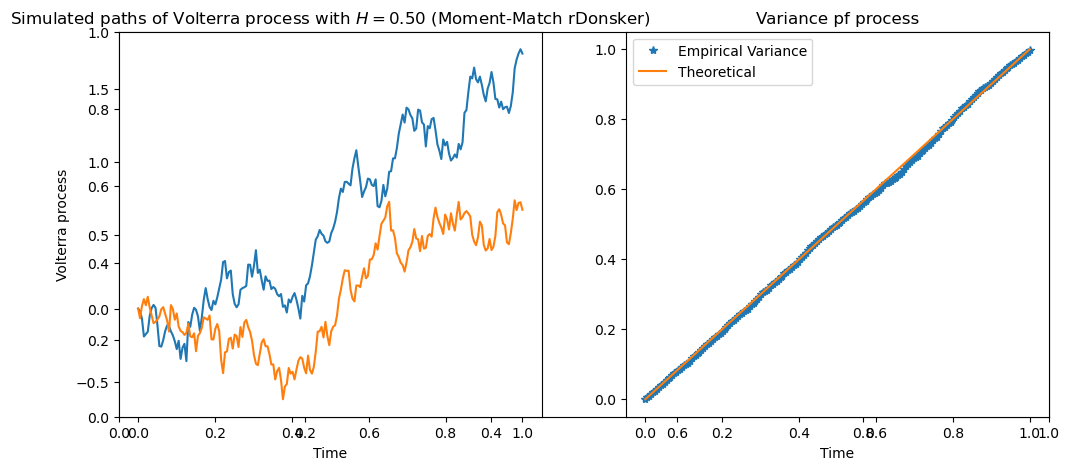

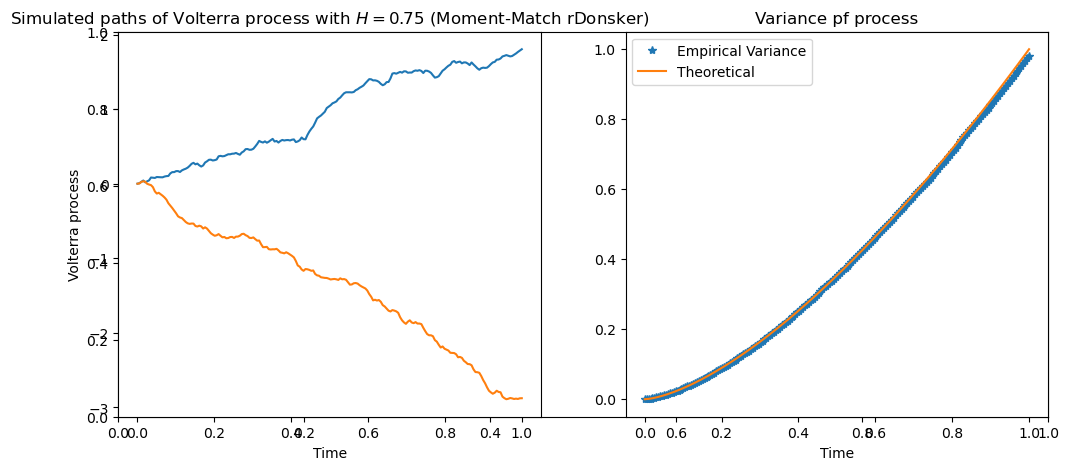

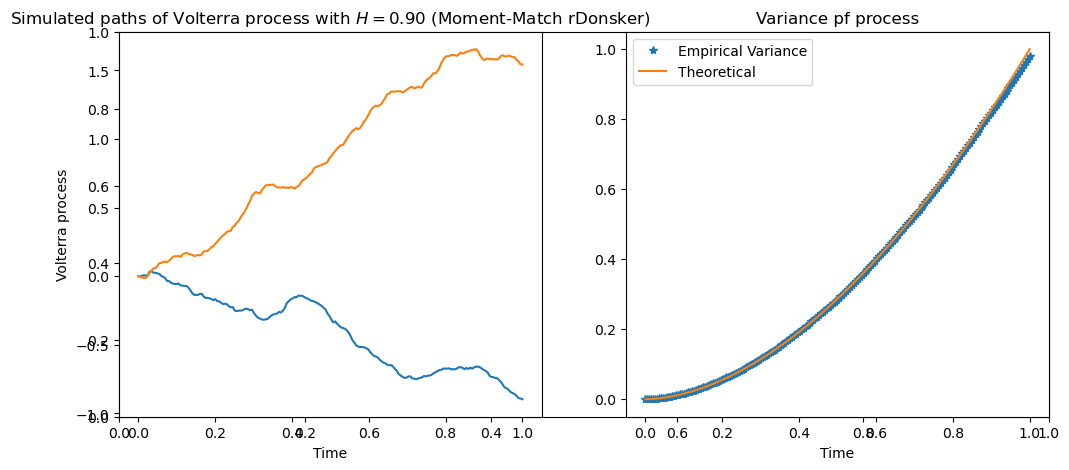

In [136]:
def fBm_path_rDonsker1(grid_points: int, M: int, H: float, T: float) -> np.ndarray:
    """
    rDonsker fractional Brownian motion paths with correct variance scaling.
    Ensures Var[X_t] ≈ t^{2H}.
    """
    dt = 1 / (grid_points - 1)
    dw = np.random.normal(0.0, (dt**H), size=(M, grid_points - 1))
    i = np.arange(1, grid_points)
    # "Optimal" Donsker kernel (from Bayer, Friz, Gatheral 2016)
    opt_k = ((i**(2*H) - (i-1)**(2*H)) / (2*H)) ** 0.5

    Y = np.zeros((M, grid_points))
    for m in range(M):
        conv = np.convolve(opt_k, dw[m, :])[:grid_points - 1]
        Y[m, 1:] = conv

    # empirically normalize to Var[X_T] = T^{2H}
    scale = T**H * np.sqrt(2*H)
    Y *= scale
    return Y


import matplotlib.pyplot as plt


T=1
n=200
M=5000

Hs = [0.05,0.25,0.5,0.75,0.9]

times=np.linspace(0,T,n)

for H in Hs:
    
    path=fBm_path_rDonsker1(n, M, H, T)
    
    plt.subplots(figsize=(12, 5))
    for i in range(2):
        plt.subplot(1,2,1)
        plt.plot(times,path[i,:])
        
        
    plt.xlabel('Time')
    plt.ylabel('Volterra process')
    plt.title('Simulated paths of Volterra process with $H=%1.2f$ (Moment-Match rDonsker)'%H)
    plt.subplot(1,2,2)
    plt.title('Variance pf process')
    plt.xlabel('Time')
    plt.plot(times,np.var(path,axis=0),'*',label="Empirical Variance")
    plt.plot(times,np.power(times,2*H),label="Theoretical")
    plt.legend()
    plt.show()
        





In [ ]:
test2

NameError: name 'test' is not defined